In [ ]:
!pip install opencv-python

In [2]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow # Special patch for Colab

# Upload an image file (jpg, png)
print("Please upload an image with a face:")
uploaded = files.upload()

# Get the filename
filename = list(uploaded.keys())[0]

Please upload an image with a face:


Saving download.jpg to download.jpg


Detected 1 face(s)


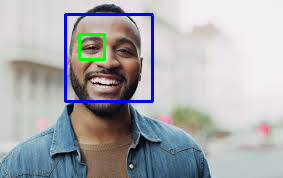

In [3]:
# 1. Load the pre-trained Viola-Jones Face Cascade
# OpenCV provides these by default in their data folder
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_eye.xml')

# 2. Read the uploaded image
img = cv2.imread(filename)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # The algorithm requires grayscale

# 3. Detect Faces
# scaleFactor: How much the image size is reduced at each image scale
# minNeighbors: How many neighbors each candidate rectangle should have to retain it
faces = face_cascade.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5, minSize=(30, 30))

print(f"Detected {len(faces)} face(s)")

# 4. Draw rectangles around the faces and eyes
for (x, y, w, h) in faces:
    cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2) # Blue box for face

    # Region of Interest (ROI) for eyes (within the face)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = img[y:y+h, x:x+w]

    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0, 255, 0), 2) # Green box for eyes

# 5. Display the result
cv2_imshow(img)

In [ ]:
haarcascade_frontalface_default.xml → front face
haarcascade_frontalface_alt.xml
haarcascade_profileface.xml → side face
haarcascade_eye.xml → eyes
haarcascade_smile.xml → smile
haarcascade_fullbody.xml → full body